In [11]:
# Monte Carlo simulation of 2024 tournament using saved model
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

import re
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import math

In [12]:
# Define paths for model and tournament data
MODEL_PATH = Path("models/xgb_march_madness_model.joblib")

# Path to matchup features CSV
MATCHUPS_PATH = Path("data/processed/MNCAATourneyMatchupFeatures.csv")

# Load matchup features
df_matchups = pd.read_csv(MATCHUPS_PATH)

# Load trained model
model = joblib.load(MODEL_PATH)

In [13]:
# Simulate tournament matchups from processed feature differences

# Select numeric feature columns (robust to minor column variations)
numeric_cols = df_matchups.select_dtypes(include=["number"]).columns.tolist()

# If a known expected feature set exists, intersect to ensure order
expected_feat_cols = [
    "eFG_diff", "TOVp_diff", "ORBp_diff", "FTR_diff",
    "ORtg_diff", "DRtg_diff", "win_rate_diff", "seed_num_diff",
]
feat_cols = [c for c in expected_feat_cols if c in numeric_cols]
if not feat_cols:
    # Fall back to using all numeric columns
    feat_cols = numeric_cols

# Prefer the exact feature names used by the trained model when available
feat_names = getattr(model, "feature_names_in_", None)
if feat_names is not None:
    # Keep only those the model expects; preserve order
    feat_cols = [c for c in feat_names if c in (set(numeric_cols) | set(expected_feat_cols))]
    # If still empty for any reason, keep the earlier detection
    if not feat_cols:
        feat_cols = list(feat_names)

In [14]:
# Build and simulate the NCAA bracket using Seeds and Slots
import re
from collections import defaultdict, deque

# Paths to Kaggle data and team features
DATA_ROOT = Path("data/relevant_data")
SEEDS_PATH = DATA_ROOT / "MNCAATourneySeeds.csv"
SLOTS_PATH = DATA_ROOT / "MNCAATourneySlots.csv"
TEAMS_PATH = DATA_ROOT / "MTeams.csv"
TEAM_FEATURES_PATH = Path("data/processed/team_data.csv")

# Load datasets
seeds_df = pd.read_csv(SEEDS_PATH)
slots_df = pd.read_csv(SLOTS_PATH)
teams_df = pd.read_csv(TEAMS_PATH)

# Optional: team-level features per season for feature diffs
team_feat_df = None
if TEAM_FEATURES_PATH.exists():
    team_feat_df = pd.read_csv(TEAM_FEATURES_PATH)

# Choose the season to simulate: prefer 2024 if available else the latest in common
available_seasons = sorted(set(seeds_df["Season"]).intersection(set(slots_df["Season"])))
latest_season = 2026  # 2024 if 2024 in available_seasons else max(available_seasons)

# Filter season data
seeds = seeds_df[seeds_df["Season"] == latest_season].copy()
slots = slots_df[slots_df["Season"] == latest_season].copy()

# Helpers
seed_num_re = re.compile(r"^[WXYZ](\d{2})[ab]?$", re.I)

def seed_number(seed_str: str) -> int:
    m = seed_num_re.match(seed_str)
    return int(m.group(1)) if m else 99

# Map seed -> team for the season (includes play-in a/b seeds)
seed_to_teamid = dict(zip(seeds["Seed"], seeds["TeamID"]))

# Map TeamID -> TeamName for pretty printing
team_name = dict(zip(teams_df["TeamID"], teams_df["TeamName"]))

# Optionally, build per-season team features for quick access
team_features = {}
if team_feat_df is not None and "Season" in team_feat_df.columns and "TeamID" in team_feat_df.columns:
    # keep only this season if present
    tf = team_feat_df.copy()
    if latest_season in set(tf.get("Season", pd.Series([], dtype=int))):
        tf = tf[tf["Season"] == latest_season]
    for _, r in tf.iterrows():
        team_features[int(r["TeamID"])] = r.to_dict()

# Determine which base stat columns we can use to construct diffs
base_feat_cols = ["eFG", "TOVp", "ORBp", "FTR", "ORtg", "DRtg", "win_rate"]
avail_cols = []
if team_features:
    # Inspect any one row to detect available columns
    sample = next(iter(team_features.values()))
    avail_cols = [c for c in base_feat_cols if c in sample]

# Construct a single-row feature vector for a matchup (A vs B)
# Returns: (X_df[feat_cols], feature_column_names actually provided)
def build_feature_row(team_a: int, team_b: int, seed_a: str, seed_b: str):
    row_vals = {}

    # From team features if available
    if avail_cols:
        fa = team_features.get(team_a, {})
        fb = team_features.get(team_b, {})
        for c in avail_cols:
            row_vals[f"{c}_diff"] = float(fa.get(c, np.nan)) - float(fb.get(c, np.nan))

    # Seed number diff (align with training: positive favors Team A)
    # Training used seed_num_diff = seed2 - seed1 (Team1 advantage -> positive)
    row_vals["seed_num_diff"] = seed_number(seed_b) - seed_number(seed_a)

    # From precomputed matchup features CSV if present and provides more fields
    # Try to find a direct row for this exact A,B pair (any reasonable column naming)
    # This is optional enrichment; we'll only add fields that aren't already present
    candidate = None
    if 'Season' in df_matchups.columns:
        # Try common id column names
        id_pairs = [
            ("TeamAID", "TeamBID"), ("Team1ID", "Team2ID"), ("A_TeamID", "B_TeamID"),
        ]
        for ca, cb in id_pairs:
            if ca in df_matchups.columns and cb in df_matchups.columns:
                sub = df_matchups[(df_matchups["Season"] == latest_season) &
                                  (df_matchups[ca] == team_a) & (df_matchups[cb] == team_b)]
                if not sub.empty:
                    candidate = sub.iloc[0].to_dict()
                    break
    if candidate is not None:
        for k, v in candidate.items():
            if k.endswith("_diff") and k not in row_vals and isinstance(v, (int, float, np.floating)):
                row_vals[k] = float(v)

    # Build DataFrame with only the columns our model will consume
    # Use feat_cols computed earlier, but only those present in row_vals
    use_cols = [c for c in feat_cols if c in row_vals]
    # If nothing matched, fall back to any numeric diffs we computed
    if not use_cols:
        use_cols = [k for k in row_vals.keys() if k.endswith("_diff") or k == "seed_num_diff"]

    X_row = pd.DataFrame([[row_vals.get(c, 0.0) for c in use_cols]], columns=use_cols)
    return X_row, use_cols

# ---- Probability calibration helpers ----
# Calibrated column index for "Team A wins"
_WIN_COL = int(np.where(getattr(model, "classes_", np.array([0, 1])) == 1)[0][0]) if hasattr(model, "classes_") else 1

def _to_model_X(X_row: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Reorder / align a single-row DataFrame to the model's expected feature order."""
    feat_names = getattr(model, "feature_names_in_", None)
    if feat_names is None:
        # Fall back: assume current column order is acceptable
        return X_row
    # Build full row in expected order, filling missing with 0.0
    vals = []
    for c in feat_names:
        if c in X_row.columns:
            vals.append(float(X_row[c].iloc[0]))
        else:
            vals.append(0.0)
    return pd.DataFrame([vals], columns=list(feat_names))

def predict_matchup_prob(team_a: int, team_b: int, seed_a: str, seed_b: str) -> float:
    """Return P(Team A wins) from the trained model."""
    # Build features for orientation A vs B
    Xa_row, cols_a = build_feature_row(team_a, team_b, seed_a, seed_b)
    Xa = _to_model_X(Xa_row, cols_a)

    # Probability Team A (Team1) wins is the positive class index
    pA = float(model.predict_proba(Xa)[0][_WIN_COL])
    return pA

def simulate_bracket_once(stochastic: bool = False, rng: np.random.Generator | None = None):
    """Simulate one full tournament bracket.

    If stochastic is False, picks the higher probability team in each game.
    If stochastic is True, samples game results according to win probabilities.

    Returns:
        winners: dict mapping slot -> (team_id, seed_str)
        match_meta: list of per-game dicts with probabilities and upset info.
    """
    if stochastic and rng is None:
        rng = np.random.default_rng()

    winners = {}  # slot -> (team_id, original_seed_str)

    def resolve(entry: str):
        # If it's a seed name in the seeds table
        if entry in seed_to_teamid:
            tid = int(seed_to_teamid[entry])
            return tid, entry
        # Else, it must refer to a prior slot
        if entry in winners:
            return winners[entry]
        return None

    remaining = set(slots["Slot"].tolist())
    match_meta = []  # keep some logs per game

    while remaining:
        progressed = False
        for _, row in slots.iterrows():
            slot = row["Slot"]
            if slot not in remaining:
                continue
            a_ref = row["StrongSeed"]
            b_ref = row["WeakSeed"]
            ra = resolve(a_ref)
            rb = resolve(b_ref)
            if ra is None or rb is None:
                continue  # can't play yet
            team_a, seed_a = ra
            team_b, seed_b = rb

            # Predict P(Team A wins)
            p_A = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
            p_B = 1.0 - p_A

            # Determine which is underdog by seed number (higher number = worse seed)
            seed_num_a = seed_number(seed_a)
            seed_num_b = seed_number(seed_b)
            if seed_num_a == seed_num_b:
                underdog = None
                p_underdog = min(p_A, p_B)
            elif seed_num_a > seed_num_b:
                underdog = "A"
                p_underdog = p_A
            else:
                underdog = "B"
                p_underdog = p_B

            # Decide winner
            if stochastic:
                # Sample outcome based on p_A
                winA = bool(rng.random() < p_A)
            else:
                # Deterministic: higher probability
                winA = p_A >= p_B

            if winA:
                win_id, win_seed, win_p, lose_id, lose_p = team_a, seed_a, p_A, team_b, p_B
            else:
                win_id, win_seed, win_p, lose_id, lose_p = team_b, seed_b, p_B, team_a, p_A

            winners[slot] = (win_id, win_seed)
            remaining.remove(slot)
            progressed = True

            a_label = f"{team_name.get(team_a, team_a)} ({seed_a})"
            b_label = f"{team_name.get(team_b, team_b)} ({seed_b})"

            # Mark whether the realized result was an upset (winner was underdog by seed)
            realized_upset = False
            if underdog == "A" and winA:
                realized_upset = True
            elif underdog == "B" and not winA:
                realized_upset = True

            match_meta.append({
                "slot": slot,
                "A": a_label,
                "B": b_label,
                "seedA": seed_a,
                "seedB": seed_b,
                "seed_num_A": seed_num_a,
                "seed_num_B": seed_num_b,
                "pA": float(round(p_A, 4)),
                "pB": float(round(p_B, 4)),
                "winner": team_name.get(win_id, win_id),
                "winner_seed": win_seed,
                "winner_p": float(round(win_p, 4)),
                "winA": winA,
                "underdog_side": underdog,
                "p_underdog": float(round(p_underdog, 4)),
                "realized_upset": realized_upset,
            })
        if not progressed:
            # Safety to avoid infinite loop if data inconsistent
            break

    return winners, match_meta

# --- Single deterministic simulation (for bracket drawing) ---
winners, match_meta = simulate_bracket_once(stochastic=False)

# Determine champion: final slot is the one that's referenced by no other slot
referenced = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
final_slots = [s for s in slots["Slot"].tolist() if s not in referenced]
champ_slot = final_slots[0] if final_slots else slots.iloc[-1]["Slot"]
champ_id, champ_seed = winners.get(champ_slot, (None, None))
champ_name = team_name.get(champ_id, str(champ_id)) if champ_id is not None else "Unknown"

print(f"Season {latest_season} champion (deterministic): {champ_name} ({champ_seed})")

# Show a concise per-round summary
# Build reverse graph: for each slot, which next slot consumes it
consumers = defaultdict(list)
for _, r in slots.iterrows():
    consumers[r["StrongSeed"].item() if hasattr(r["StrongSeed"], 'item') else r["StrongSeed"]].append(r["Slot"])
    consumers[r["WeakSeed"].item() if hasattr(r["WeakSeed"], 'item') else r["WeakSeed"]].append(r["Slot"])

# Determine round number by BFS from seeds to final
round_of = {}
q = deque()
# Initial entries are the seeds that appear in any slot
seed_entries = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
for e in seed_entries:
    if e in seed_to_teamid:  # actual seeds
        round_of[e] = 0
        q.append(e)
while q:
    e = q.popleft()
    rnum = round_of[e]
    for nxt in consumers.get(e, []):
        if nxt not in round_of:
            round_of[nxt] = rnum + 1
            q.append(nxt)

# Group matches by round number of their slot
round_matches = defaultdict(list)
for m in match_meta:
    rnd = round_of.get(m["slot"], -1)
    round_matches[rnd].append(m)

for rnd in sorted(round_matches.keys()):
    print(f"\nRound {rnd} results:")
    for m in round_matches[rnd]:
        upset_flag = " (UPSET)" if m["realized_upset"] else ""
        print(f"  {m['slot']}: {m['A']} vs {m['B']} -> Winner: {m['winner']} (p={m['winner_p']}, p_underdog={m['p_underdog']}){upset_flag}")

Season 2026 champion (deterministic): Arizona (Z01)

Round 1 results:
  R1W1: Duke (W01) vs Siena (W16) -> Winner: Duke (p=0.8675, p_underdog=0.1325)
  R1W2: Connecticut (W02) vs Furman (W15) -> Winner: Connecticut (p=0.8509, p_underdog=0.1491)
  R1W3: Michigan St (W03) vs N Dakota St (W14) -> Winner: Michigan St (p=0.7941, p_underdog=0.2059)
  R1W4: Kansas (W04) vs Cal Baptist (W13) -> Winner: Kansas (p=0.7322, p_underdog=0.2678)
  R1W5: St John's (W05) vs Northern Iowa (W12) -> Winner: St John's (p=0.6274, p_underdog=0.3726)
  R1W6: Louisville (W06) vs South Florida (W11) -> Winner: Louisville (p=0.5118, p_underdog=0.4882)
  R1W7: UCLA (W07) vs UCF (W10) -> Winner: UCLA (p=0.6116, p_underdog=0.3884)
  R1W8: Ohio St (W08) vs TCU (W09) -> Winner: Ohio St (p=0.522, p_underdog=0.478)
  R1X2: Houston (X02) vs Idaho (X15) -> Winner: Houston (p=0.8509, p_underdog=0.1491)
  R1X3: Illinois (X03) vs Penn (X14) -> Winner: Illinois (p=0.7941, p_underdog=0.2059)
  R1X4: Nebraska (X04) vs Troy (X1

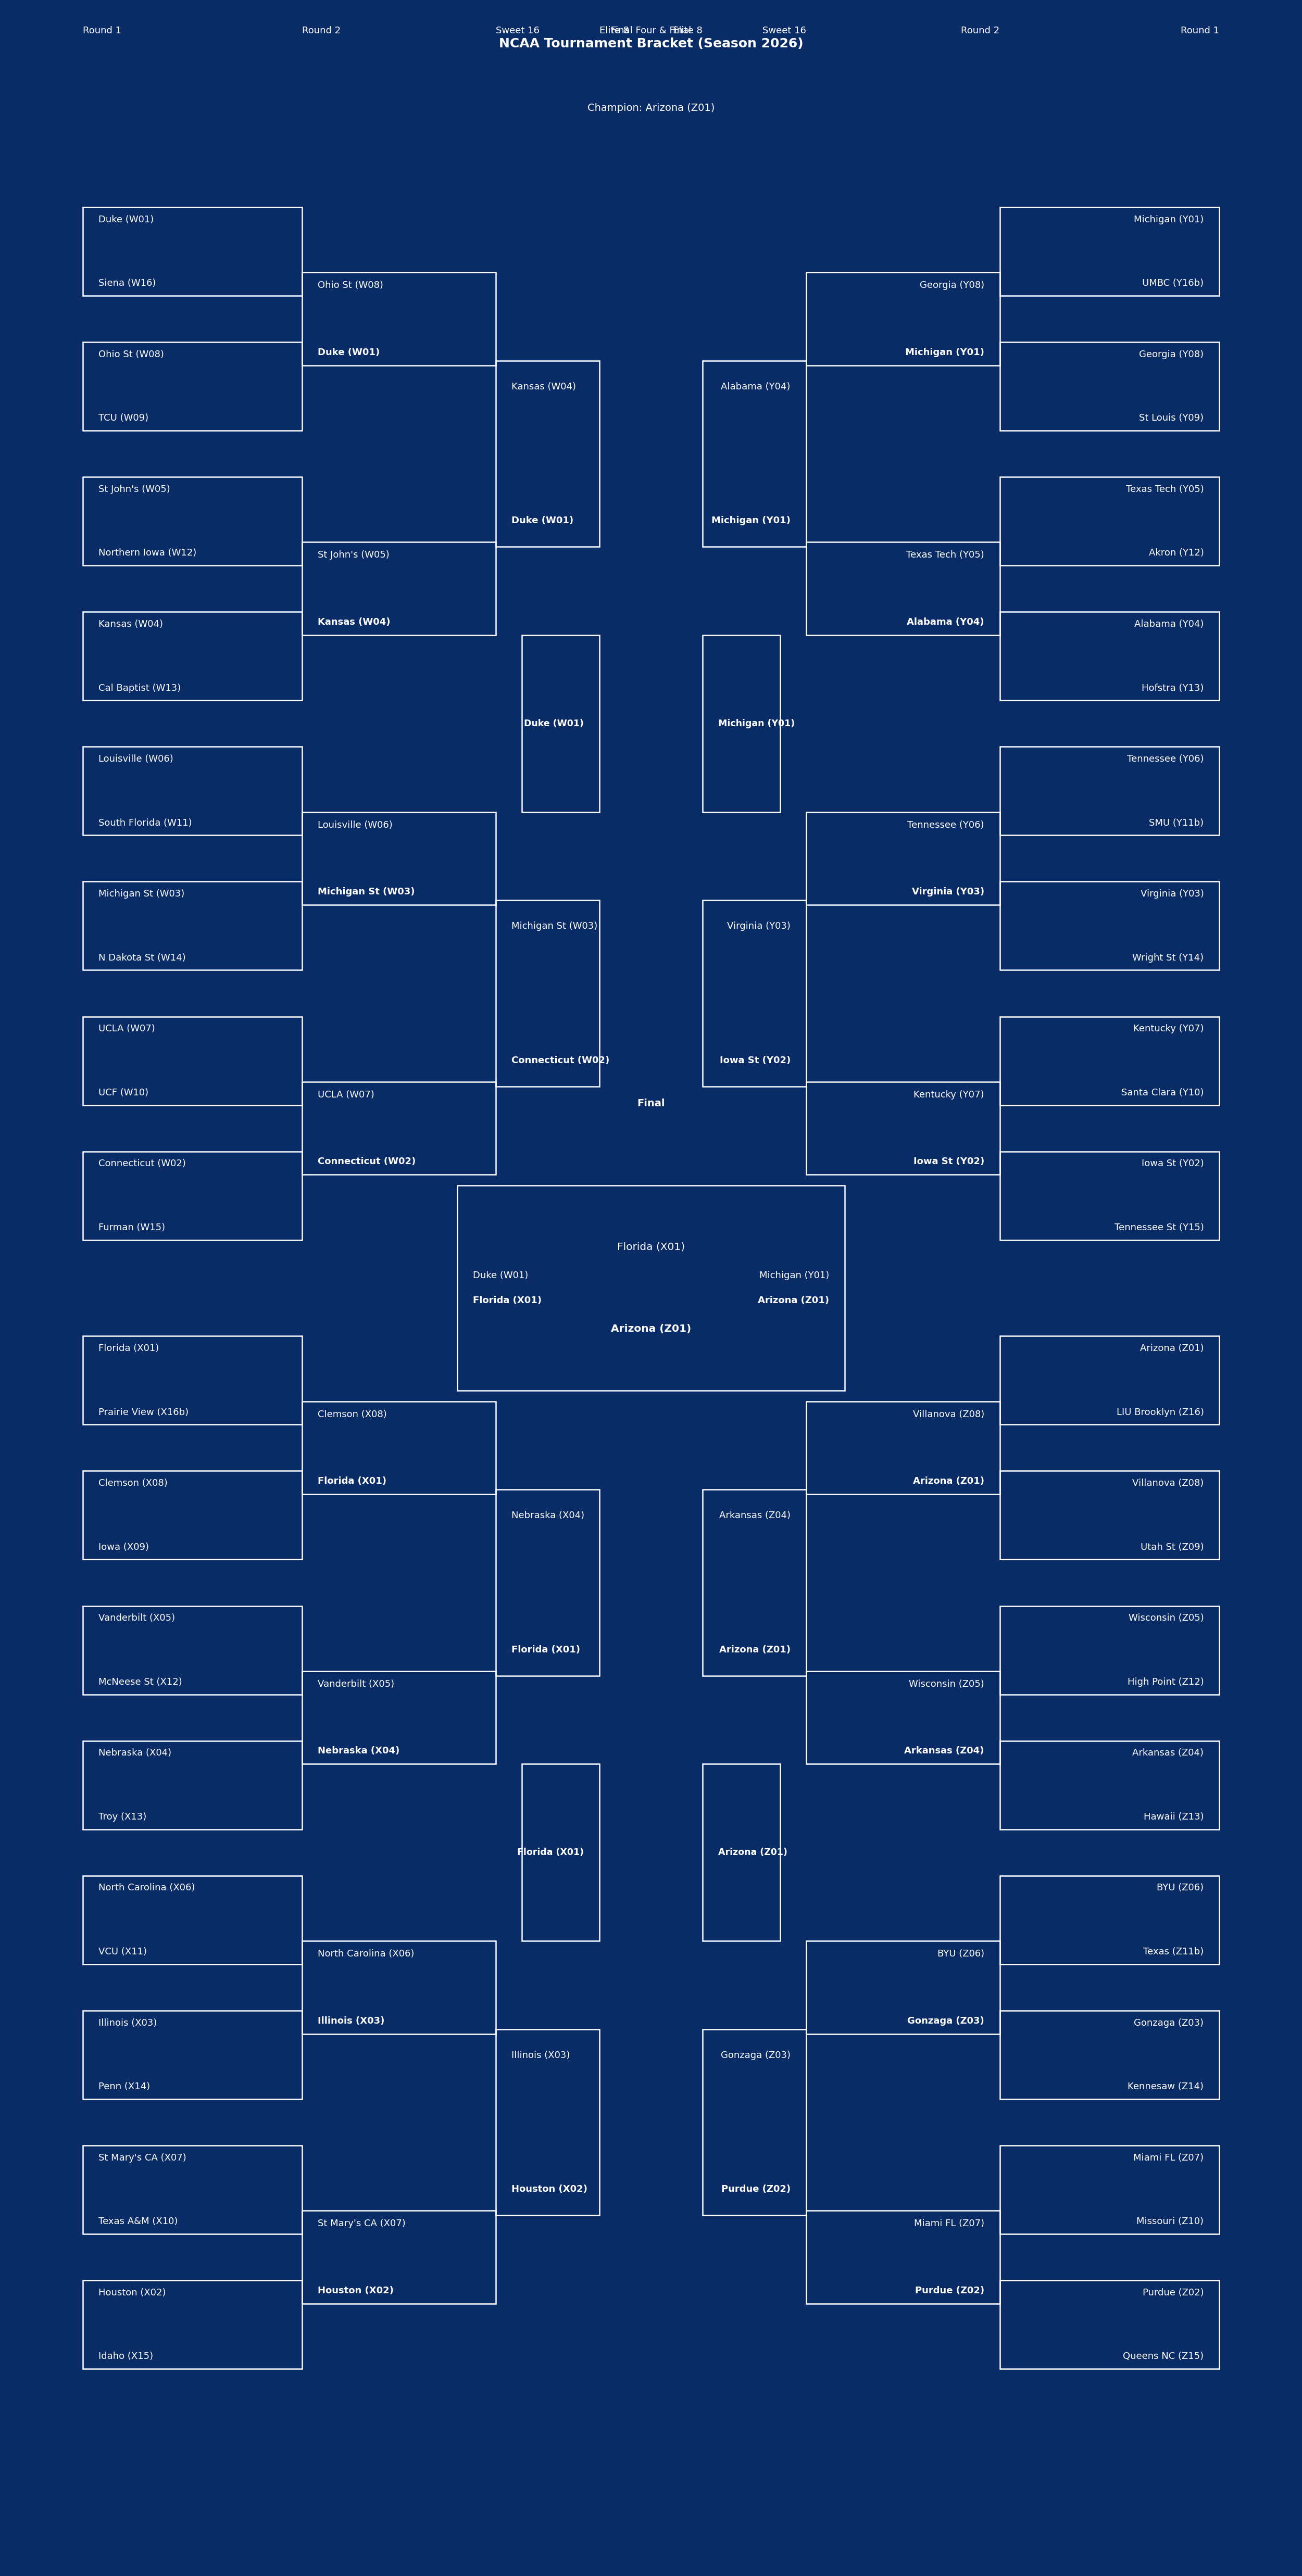

In [15]:
def render_bracket(
    match_meta,
    round_of,
    latest_season,
    champ_name,
    champ_seed,
    left_regions=('W', 'X'),
    right_regions=('Y', 'Z'),
    fig_w=16,
    fig_h=8,
    bg_color='#0A2C66',
    text_color='white'
):
    """
    Render a tournament bracket figure.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    # --- Helpers to parse labels ---
    seed_pat_local = re.compile(r"\(([^)]+)\)$")

    def parse_seed(label: str) -> str:
        m = seed_pat_local.search(label)
        return m.group(1) if m else ""

    def seed_region(seed: str) -> str:
        return seed[:1].upper() if seed else ""

    def seed_num(seed: str) -> int:
        s = seed.rstrip('abAB')
        if s and s[0].isalpha():
            s = s[1:]
        try:
            return int(s)
        except Exception:
            return 99

    # Canonical first-round pair order within a region
    canonical_pairs = [(1,16),(8,9),(5,12),(4,13),(6,11),(3,14),(7,10),(2,15)]
    order_index = {tuple(sorted(p)): i for i, p in enumerate(canonical_pairs)}
    seed_to_pair_idx = {s:i for i,(a,b) in enumerate(canonical_pairs) for s in (a,b)}

    left_regions = list(left_regions)
    right_regions = list(right_regions)
    all_regions = left_regions + right_regions

    # Build round 1 pairs per region (skip play-ins)
    r1_matches = [m for m in match_meta if round_of.get(m['slot'], -1) == 1]
    region_pairs = {r: [] for r in all_regions}
    for m in r1_matches:
        sA = parse_seed(m['A']); sB = parse_seed(m['B'])
        rA = seed_region(sA); rB = seed_region(sB)
        if rA and rA == rB and rA in region_pairs:
            idx = order_index.get(tuple(sorted((seed_num(sA), seed_num(sB)))), None)
            if idx is None:
                continue
            region_pairs[rA].append({'idx': idx, 'A': m['A'], 'B': m['B']})
    for r in region_pairs:
        region_pairs[r].sort(key=lambda x: x['idx'])
        region_pairs[r] = region_pairs[r][:8]

    # Collect matches per round per region
    region_rounds = {r: {1: [], 2: [], 3: [], 4: []} for r in all_regions}
    for m in match_meta:
        sA = parse_seed(m['A']); sB = parse_seed(m['B'])
        rA = seed_region(sA); rB = seed_region(sB)
        rnd = round_of.get(m['slot'], -1)
        if rA == rB and rA in region_rounds and rnd in (1,2,3,4):
            region_rounds[rA][rnd].append(m)

    # Sort later rounds for reproducibility
    for r in all_regions:
        for rnd in (2,3,4):
            region_rounds[r][rnd].sort(
                key=lambda m: min(seed_num(parse_seed(m['A'])),
                                  seed_num(parse_seed(m['B'])))
            )

    regional_champs = {r: None for r in all_regions}
    for r in all_regions:
        if region_rounds[r][4]:
            mm = region_rounds[r][4][0]
            regional_champs[r] = (mm['winner'], mm['winner_seed'])

    # Final Four and Final
    final_four = []
    final_match = None
    for m in match_meta:
        sA = parse_seed(m['A']); sB = parse_seed(m['B'])
        rA = seed_region(sA); rB = seed_region(sB)
        rnd = round_of.get(m['slot'], -1)
        if rnd >= 5 and (not rA or not rB or rA != rB):
            if rnd == 5:
                final_four.append(m)
            else:
                final_match = m

    # --- Layout parameters / figure ---
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor(bg_color)
    fig.patch.set_facecolor(bg_color)

    # Column x-positions (ensure gap around center)
    cols_left = [0.06, 0.23, 0.38, 0.46]
    cols_center = 0.50
    cols_right = [0.94, 0.77, 0.62, 0.54]

    # Region bands (top -> bottom)
    band_left = {'W': (0.92, 0.52), 'X': (0.48, 0.08)}
    band_right = {'Y': (0.92, 0.52), 'Z': (0.48, 0.08)}

    # --- drawing helpers ---

    def draw_box(x_left, x_right, y_center, height, edge='white', face='none', lw=1.8):
        xl, xr = (x_left, x_right) if x_left <= x_right else (x_right, x_left)
        w = (xr - xl)
        rect = patches.Rectangle(
            (xl, y_center - height/2.0), w, height,
            linewidth=lw, edgecolor=edge, facecolor=face
        )
        ax.add_patch(rect)
        return xl, xr

    def draw_boxed_match(
        x_left, x_right, y_center, box_h,
        team1, team2,
        align='left', winner_idx=None, fontsize=13
    ):
        inset = 0.012
        xl, xr = draw_box(x_left, x_right, y_center, box_h)
        y_gap = box_h * 0.36
        if align == 'right':
            x_text = xr - inset
            ha = 'right'
        elif align == 'center':
            x_text = (xl + xr) / 2.0
            ha = 'center'
        else:
            x_text = xl + inset
            ha = 'left'
        fw1 = 'bold' if winner_idx == 0 else 'normal'
        fw2 = 'bold' if winner_idx == 1 else 'normal'
        ax.text(x_text, y_center + y_gap, team1,
                color=text_color, ha=ha, va='center',
                fontsize=fontsize, fontweight=fw1)
        ax.text(x_text, y_center - y_gap, team2,
                color=text_color, ha=ha, va='center',
                fontsize=fontsize, fontweight=fw2)

    def draw_region(region: str, side: str):
        if side == 'left':
            x_cols = cols_left
            y_top, y_bot = band_left[region]
            align = 'left'
        else:
            x_cols = cols_right
            y_top, y_bot = band_right[region]
            align = 'right'

        pairs = region_pairs.get(region, [])
        n_pairs = len(pairs)
        if n_pairs == 0:
            return {'ys_r1': [], 'ys_r2': [], 'ys_r3': [], 'y_ch': None}

        H = abs(y_top - y_bot)
        step = H / n_pairs
        band_pad = step * 0.18
        inner_gap1 = step * 0.46
        box_h_r1 = inner_gap1 * 1.5
        pair_centers = np.linspace(
            y_top - step/2 + band_pad,
            y_bot + step/2 - band_pad,
            n_pairs
        )

        ys_r1 = []
        for i in range(n_pairs):
            rec = pairs[i]
            y_mid = pair_centers[i]
            ys_r1.append(y_mid)
            draw_boxed_match(
                x_cols[0], x_cols[1], y_mid, box_h_r1,
                rec['A'], rec['B'], align=align,
                winner_idx=None, fontsize=13
            )

        ys_r2 = [
            (ys_r1[2*k] + ys_r1[2*k+1]) / 2.0
            for k in range(max(1, n_pairs//2))
        ]
        inner_gap2 = (ys_r1[1] - ys_r1[0]) * 0.46 if n_pairs > 1 else inner_gap1
        box_h_r2 = inner_gap2 * 1.5

        matches_r2 = region_rounds[region][2]
        for m in matches_r2:
            sA = seed_num(parse_seed(m['A']))
            sB = seed_num(parse_seed(m['B']))
            pA = seed_to_pair_idx.get(sA, 0)
            pB = seed_to_pair_idx.get(sB, 0)
            grp = min(pA, pB) // 2
            if grp < len(ys_r2):
                y = ys_r2[grp]
                winner_idx = 0 if m.get('winA', False) else 1
                draw_boxed_match(
                    x_cols[1], x_cols[2], y, box_h_r2,
                    m['A'], m['B'],
                    align=align, winner_idx=winner_idx, fontsize=13
                )

        ys_r3 = [
            (ys_r2[2*k] + ys_r2[2*k+1]) / 2.0
            for k in range(max(1, len(ys_r2)//2))
        ]
        inner_gap3 = (ys_r2[1] - ys_r2[0]) * 0.46 if len(ys_r2) > 1 else inner_gap2
        box_h_r3 = inner_gap3 * 1.5

        matches_r3 = region_rounds[region][3]
        for m in matches_r3:
            sA = seed_num(parse_seed(m['A']))
            sB = seed_num(parse_seed(m['B']))
            pA = seed_to_pair_idx.get(sA, 0)
            pB = seed_to_pair_idx.get(sB, 0)
            grp2 = (min(pA, pB) // 2) // 2
            if grp2 < len(ys_r3):
                y = ys_r3[grp2]
                winner_idx = 0 if m.get('winA', False) else 1
                draw_boxed_match(
                    x_cols[2], x_cols[3], y, box_h_r3,
                    m['A'], m['B'],
                    align=align, winner_idx=winner_idx, fontsize=13
                )

        champ = regional_champs.get(region)
        y_ch = None
        if champ:
            if len(ys_r3) >= 2:
                y_ch = (ys_r3[0] + ys_r3[1]) / 2.0
            elif ys_r3:
                y_ch = ys_r3[0]
            else:
                y_ch = np.mean([y_top, y_bot])

            if side == 'left':
                draw_box(x_cols[3]-0.06, x_cols[3], y_ch, box_h_r3*0.95)
                ax.text(
                    x_cols[3]-0.012, y_ch,
                    f"{champ[0]} ({champ[1]})",
                    color=text_color, ha='right', va='center',
                    fontsize=12.5, fontweight='bold'
                )
            else:
                draw_box(x_cols[3], x_cols[3]+0.06, y_ch, box_h_r3*0.95)
                ax.text(
                    x_cols[3]+0.012, y_ch,
                    f"{champ[0]} ({champ[1]})",
                    color=text_color, ha='left', va='center',
                    fontsize=12.5, fontweight='bold'
                )

        return {'ys_r1': ys_r1, 'ys_r2': ys_r2, 'ys_r3': ys_r3, 'y_ch': y_ch}

    # Draw regions and collect champion y-positions
    pos_left = {r: draw_region(r, side='left') for r in left_regions}
    pos_right = {r: draw_region(r, side='right') for r in right_regions}

    # Compute semifinal centers
    y_sem_left = None
    y_sem_right = None
    if (pos_left.get('W', {}).get('y_ch') is not None and
        pos_left.get('X', {}).get('y_ch') is not None):
        y_sem_left = (pos_left['W']['y_ch'] + pos_left['X']['y_ch']) / 2.0
    if (pos_right.get('Y', {}).get('y_ch') is not None and
        pos_right.get('Z', {}).get('y_ch') is not None):
        y_sem_right = (pos_right['Y']['y_ch'] + pos_right['Z']['y_ch']) / 2.0

    center_pad = 0.08
    if y_sem_left is not None:
        y_sem_left -= center_pad
    if y_sem_right is not None:
        y_sem_right += center_pad

    # Final box
    if final_match and y_sem_left is not None and y_sem_right is not None:
        y_final = (y_sem_left + y_sem_right) / 2.0
        final_width = 0.30
        final_height = 0.08
        xl, xr = draw_box(
            cols_center-final_width/2,
            cols_center+final_width/2,
            y_final, final_height
        )

        ax.text(
            cols_center,
            y_final + (final_height/2) + 0.030,
            "Final",
            color=text_color, ha='center', va='bottom',
            fontsize=14, fontweight='bold'
        )

        inset = 0.012
        semi_line_gap = final_height * 0.06

        # Left semi
        if len(final_four) >= 1:
            m_left = final_four[0]
            y1 = y_final + semi_line_gap
            y2 = y_final - semi_line_gap
            fw1 = 'bold' if m_left.get('winA', False) else 'normal'
            fw2 = 'bold' if not m_left.get('winA', False) else 'normal'
            ax.text(
                xl + inset, y1, m_left['A'],
                color=text_color, ha='left', va='center',
                fontsize=13, fontweight=fw1
            )
            ax.text(
                xl + inset, y2, m_left['B'],
                color=text_color, ha='left', va='center',
                fontsize=13, fontweight=fw2
            )

        # Right semi
        if len(final_four) >= 2:
            m_right = final_four[1]
            y1 = y_final + semi_line_gap
            y2 = y_final - semi_line_gap
            fw1 = 'bold' if m_right.get('winA', False) else 'normal'
            fw2 = 'bold' if not m_right.get('winA', False) else 'normal'
            ax.text(
                xr - inset, y1, m_right['A'],
                color=text_color, ha='right', va='center',
                fontsize=13, fontweight=fw1
            )
            ax.text(
                xr - inset, y2, m_right['B'],
                color=text_color, ha='right', va='center',
                fontsize=13, fontweight=fw2
            )

        # Finalists
        y_gap = final_height * 0.20
        fwA = 'bold' if final_match.get('winA', False) else 'normal'
        fwB = 'bold' if not final_match.get('winA', False) else 'normal'
        ax.text(
            cols_center, y_final + y_gap, final_match['A'],
            color=text_color, ha='center', va='center',
            fontsize=14.5, fontweight=fwA
        )
        ax.text(
            cols_center, y_final - y_gap, final_match['B'],
            color=text_color, ha='center', va='center',
            fontsize=14.5, fontweight=fwB
        )

    # Title and champion
    ax.text(
        0.5, 0.985,
        f"NCAA Tournament Bracket (Season {latest_season})",
        color=text_color, ha='center', va='center',
        fontsize=18, fontweight='bold'
    )
    ax.text(
        0.5, 0.96,
        f"Champion: {champ_name} ({champ_seed})",
        color=text_color, ha='center', va='center',
        fontsize=14
    )

    # Round headings
    ax.text(cols_left[0], 0.99, 'Round 1', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_left[1], 0.99, 'Round 2', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_left[2], 0.99, 'Sweet 16', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_left[3], 0.99, 'Elite 8', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_center, 0.99, 'Final Four & Final', color=text_color,
            ha='center', va='center', fontsize=13)
    ax.text(cols_right[3], 0.99, 'Elite 8', color=text_color,
            ha='right', va='center', fontsize=13)
    ax.text(cols_right[2], 0.99, 'Sweet 16', color=text_color,
            ha='right', va='center', fontsize=13)
    ax.text(cols_right[1], 0.99, 'Round 2', color=text_color,
            ha='right', va='center', fontsize=13)
    ax.text(cols_right[0], 0.99, 'Round 1', color=text_color,
            ha='right', va='center', fontsize=13)

    # Resize before render; caller can override if desired
    w, h = fig.get_size_inches()
    fig.set_size_inches(w * 2, h * 8, forward=True)

    return fig, ax

# Render the bracket figure
fig, ax = render_bracket(
    match_meta, round_of, latest_season, champ_name, champ_seed,
    left_regions=('W', 'X'), right_regions=('Y', 'Z'),
    fig_w=16, fig_h=8,
    bg_color='#0A2C66', text_color='white'
)

In [16]:
# Monte Carlo simulation to estimate upset frequencies across brackets

def run_monte_carlo_brackets(n_sim: int = 1000, upset_seed_gap: int = 2, rng_seed: int = 42):
    """Run many stochastic bracket simulations and estimate upset frequencies.

    Args:
        n_sim: number of bracket simulations.
        upset_seed_gap: minimum seed-number gap to count as an upset candidate
                        (e.g. 2 means 5 vs 7 is not an upset, 5 vs 8 is).
        rng_seed: seed for reproducible randomness.

    Returns:
        upset_summary: DataFrame with per-slot upset stats.
    """
    rng = np.random.default_rng(rng_seed)

    # Aggregate stats keyed by (slot, A_label, B_label) to keep matchups aligned
    stats = {}  # key -> dict

    max_upsets = 10

    for _ in range(n_sim):
        _, match_meta_sim = simulate_bracket_once(stochastic=True, rng=rng)
        for m in match_meta_sim:
            slot = m["slot"]
            A = m["A"]
            B = m["B"]
            key = (slot, A, B)

            # Derive seed numbers
            seed_num_A = m["seed_num_A"]
            seed_num_B = m["seed_num_B"]

            # Determine if this is an upset *candidate* based on seed gap
            seed_gap = abs(seed_num_A - seed_num_B)
            is_upset_candidate = seed_gap >= upset_seed_gap and seed_num_A != seed_num_B

            if key not in stats:
                stats[key] = {
                    "slot": slot,
                    "A": A,
                    "B": B,
                    "seedA": m["seedA"],
                    "seedB": m["seedB"],
                    "seed_num_A": seed_num_A,
                    "seed_num_B": seed_num_B,
                    "games_played": 0,
                    "upset_wins": 0,
                    "is_upset_candidate": is_upset_candidate,
                }
            rec = stats[key]

            rec["is_upset_candidate"] = rec["is_upset_candidate"] or is_upset_candidate
            rec["games_played"] += 1

            if is_upset_candidate and m["realized_upset"]:
                rec["upset_wins"] += 1

    if not stats:
        return pd.DataFrame()

    upset_df = pd.DataFrame(list(stats.values()))
    upset_df["upset_prob_given_played"] = upset_df.apply(
        lambda r: (r["upset_wins"] / r["games_played"]) if r["games_played"] > 0 else 0.0,
        axis=1,
    )
    upset_df["play_prob"] = upset_df["games_played"] / float(n_sim)
    upset_df["joint_upset_prob"] = upset_df["upset_prob_given_played"] * upset_df["play_prob"]

    # Filter to genuine upset candidates only, then keep only top 10
    upset_df = upset_df[upset_df["is_upset_candidate"]].copy()

    return upset_df.sort_values("joint_upset_prob", ascending=False).head(max_upsets)

# Use notebook-level RNG_SEED when available, otherwise fall back to 42
rng_seed_value = globals().get("RNG_SEED", 42)

# Run a modest Monte Carlo to get the top 10 likely upsets
upset_results = run_monte_carlo_brackets(
    n_sim=1000,
    upset_seed_gap=3,
    rng_seed=rng_seed_value,
)

print("Top 10 likely upsets by joint probability (prob game happens * prob underdog wins):")
cols_to_show = [
    "slot", "A", "B", "seedA", "seedB",
    "games_played", "upset_wins",
    "play_prob", "upset_prob_given_played", "joint_upset_prob",
]
display(upset_results[cols_to_show].head(10))

Top 10 likely upsets by joint probability (prob game happens * prob underdog wins):


,slot,A,B,seedA,seedB,games_played,upset_wins,play_prob,upset_prob_given_played,joint_upset_prob
5,R1W6,Louisville (W06),South Florida (W11),W06,W11,1000,517,1.0,0.517,0.517
12,R1X6,North Carolina (X06),VCU (X11),X06,X11,1000,492,1.0,0.492,0.492
19,R1Y7,Kentucky (Y07),Santa Clara (Y10),Y07,Y10,1000,396,1.0,0.396,0.396
26,R1Z7,Miami FL (Z07),Missouri (Z10),Z07,Z10,1000,393,1.0,0.393,0.393
6,R1W7,UCLA (W07),UCF (W10),W07,W10,1000,389,1.0,0.389,0.389
4,R1W5,St John's (W05),Northern Iowa (W12),W05,W12,1000,385,1.0,0.385,0.385
18,R1Y5,Texas Tech (Y05),Akron (Y12),Y05,Y12,1000,385,1.0,0.385,0.385
13,R1X7,St Mary's CA (X07),Texas A&M (X10),X07,X10,1000,385,1.0,0.385,0.385
11,R1X5,Vanderbilt (X05),McNeese St (X12),X05,X12,1000,367,1.0,0.367,0.367
25,R1Z5,Wisconsin (Z05),High Point (Z12),Z05,Z12,1000,365,1.0,0.365,0.365


In [17]:
# Use the upset data to build an "upset‑favoring" bracket and render it

# 1) Get top 10 most likely upsets using existing helper (cell 5)
topN = 10
topN_upsets = run_monte_carlo_brackets(n_sim=500, upset_seed_gap=3).head(topN)

# Represent an upset by (slot, seedA, seedB) so it is seed‑based, not label‑based
topN_seed_keys = set(
    zip(topN_upsets["slot"], topN_upsets["seedA"], topN_upsets["seedB"])
)

def build_upset_favoring_winners_seedwise(base_slots, upset_seed_keys):
    """
    Walk bracket in topological order and build a self‑consistent winners dict.
    For any matchup whose (slot, StrongSeed, WeakSeed) is in upset_seed_keys,
    force the worse seed (higher seed number) to win.
    Otherwise use the original deterministic winner if available.
    """
    winners_map = {}

    # Helper: get numeric seed from seed string like 'W06', 'X11a', etc.
    def seed_num(seed_str: str) -> int:
        return seed_number(seed_str)

    for _, row in base_slots.iterrows():
        slot = row["Slot"]
        sA = row["StrongSeed"]
        sB = row["WeakSeed"]

        # First‑four play‑in or later‑round references might point to previous slots
        def resolve_seed_or_slot(ref):
            if ref in seed_to_teamid:          # a true seed like 'W06' or 'Y16a'
                return int(seed_to_teamid[ref]), ref
            if ref in winners_map:             # a prior slot ID
                return winners_map[ref]
            if ref in winners:                 # fall back to baseline winners if consistent
                return winners[ref]
            return None

        ra = resolve_seed_or_slot(sA)
        rb = resolve_seed_or_slot(sB)
        if ra is None or rb is None:
            # Can't resolve this game yet; skip (mostly for safety)
            continue

        team_a, seed_a = ra
        team_b, seed_b = rb

        # Check if this *seed pairing* is in our upset list for this slot
        key = (slot, seed_a, seed_b)
        if key in upset_seed_keys:
            # Force the underdog win (higher numeric seed)
            if seed_num(seed_a) > seed_num(seed_b):
                winners_map[slot] = (team_a, seed_a)
            else:
                winners_map[slot] = (team_b, seed_b)
        else:
            # Use deterministic winner if defined and consistent with these teams/seeds
            if slot in winners:
                base_id, base_seed = winners[slot]
                # Only accept baseline winner if it matches one of the current teams
                if base_seed == seed_a and base_id == team_a:
                    winners_map[slot] = (team_a, seed_a)
                elif base_seed == seed_b and base_id == team_b:
                    winners_map[slot] = (team_b, seed_b)
                else:
                    # If baseline winner doesn't match (because earlier upsets changed inputs),
                    # re‑pick using probabilities.
                    pA = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
                    winners_map[slot] = (team_a, seed_a) if pA >= 0.5 else (team_b, seed_b)
            else:
                # No baseline; decide by model probability
                pA = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
                winners_map[slot] = (team_a, seed_a) if pA >= 0.5 else (team_b, seed_b)

    return winners_map

# Build a consistent winners map that propagates upsets forward
winners_upset = build_upset_favoring_winners_seedwise(slots, topN_seed_keys)

# 3) Rebuild match_meta from this winners_upset so rendering uses new paths
def rebuild_match_meta_from_winners(winners_map):
    new_match_meta = []

    for _, row in slots.iterrows():
        slot = row["Slot"]
        a_ref = row["StrongSeed"]
        b_ref = row["WeakSeed"]

        def resolve(entry):
            if entry in seed_to_teamid:
                tid = int(seed_to_teamid[entry])
                return tid, entry
            if entry in winners_map:
                return winners_map[entry]
            return None

        ra = resolve(a_ref)
        rb = resolve(b_ref)
        if ra is None or rb is None or slot not in winners_map:
            continue

        team_a, seed_a = ra
        team_b, seed_b = rb

        p_A = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
        p_B = 1.0 - p_A

        seed_num_a = seed_number(seed_a)
        seed_num_b = seed_number(seed_b)

        if seed_num_a == seed_num_b:
            underdog = None
            p_underdog = min(p_A, p_B)
        elif seed_num_a > seed_num_b:
            underdog = "A"
            p_underdog = p_A
        else:
            underdog = "B"
            p_underdog = p_B

        win_id, win_seed = winners_map[slot]
        winA = (win_id == team_a)

        if winA:
            win_p, lose_id, lose_p = p_A, team_b, p_B
        else:
            win_p, lose_id, lose_p = p_B, team_a, p_A

        a_label = f"{team_name.get(team_a, team_a)} ({seed_a})"
        b_label = f"{team_name.get(team_b, team_b)} ({seed_b})"

        realized_upset = (
            (underdog == "A" and winA) or
            (underdog == "B" and not winA)
        )

        new_match_meta.append({
            "slot": slot,
            "A": a_label,
            "B": b_label,
            "seedA": seed_a,
            "seedB": seed_b,
            "seed_num_A": seed_num_a,
            "seed_num_B": seed_num_b,
            "pA": float(round(p_A, 4)),
            "pB": float(round(p_B, 4)),
            "winner": team_name.get(win_id, win_id),
            "winner_seed": win_seed,
            "winner_p": float(round(win_p, 4)),
            "winA": winA,
            "underdog_side": underdog,
            "p_underdog": float(round(p_underdog, 4)),
            "realized_upset": realized_upset,
        })

    return new_match_meta

match_meta_upset = rebuild_match_meta_from_winners(winners_upset)

# Return matchup results by round for the upset‑favoring bracket
round_matches_upset = defaultdict(list)
for m in match_meta_upset:
    rnd = round_of.get(m["slot"], -1)
    round_matches_upset[rnd].append(m)
print("\nUpset‑favoring bracket results by round:")
for rnd in sorted(round_matches_upset.keys()):
    print(f"\nRound {rnd} results:")
    for m in round_matches_upset[rnd]:
        upset_flag = " (UPSET)" if m["realized_upset"] else ""
        print(f"  {m['slot']}: {m['A']} vs {m['B']} -> Winner: {m['winner']} (p={m['winner_p']}, p_underdog={m['p_underdog']}){upset_flag}")


Upset‑favoring bracket results by round:

Round 1 results:
  R1W1: Duke (W01) vs Siena (W16) -> Winner: Duke (p=0.8675, p_underdog=0.1325)
  R1W2: Connecticut (W02) vs Furman (W15) -> Winner: Connecticut (p=0.8509, p_underdog=0.1491)
  R1W3: Michigan St (W03) vs N Dakota St (W14) -> Winner: Michigan St (p=0.7941, p_underdog=0.2059)
  R1W4: Kansas (W04) vs Cal Baptist (W13) -> Winner: Kansas (p=0.7322, p_underdog=0.2678)
  R1W5: St John's (W05) vs Northern Iowa (W12) -> Winner: Northern Iowa (p=0.3726, p_underdog=0.3726) (UPSET)
  R1W6: Louisville (W06) vs South Florida (W11) -> Winner: South Florida (p=0.4882, p_underdog=0.4882) (UPSET)
  R1W7: UCLA (W07) vs UCF (W10) -> Winner: UCF (p=0.3884, p_underdog=0.3884) (UPSET)
  R1W8: Ohio St (W08) vs TCU (W09) -> Winner: Ohio St (p=0.522, p_underdog=0.478)
  R1X1: Florida (X01) vs Prairie View (X16b) -> Winner: Florida (p=0.8675, p_underdog=0.1325)
  R1X2: Houston (X02) vs Idaho (X15) -> Winner: Houston (p=0.8509, p_underdog=0.1491)
  R1X3:

In [18]:
# Raw Elite 8 simulation results: wins/losses by team

def simulate_elite8_win_loss_counts(n_sim: int = 1000, rng_seed: int = 42):
    rng = np.random.default_rng(rng_seed)

    elite8_matches = []
    for _, row in slots.iterrows():
        slot = row["Slot"]
        if round_of.get(slot, -1) == 4:  # Elite 8
            sA = row["StrongSeed"]
            sB = row["WeakSeed"]

            def resolve_seed_or_slot(ref):
                if ref in seed_to_teamid:
                    return int(seed_to_teamid[ref]), ref
                if ref in winners:
                    return winners[ref]
                return None

            ra = resolve_seed_or_slot(sA)
            rb = resolve_seed_or_slot(sB)
            if ra is not None and rb is not None:
                team_a, seed_a = ra
                team_b, seed_b = rb
                elite8_matches.append((team_a, seed_a, team_b, seed_b))

    team_wl = defaultdict(lambda: {"wins": 0, "losses": 0})

    for _ in range(n_sim):
        for team_a, seed_a, team_b, seed_b in elite8_matches:
            pA = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
            winA = rng.random() < pA
            winner_id = team_a if winA else team_b
            loser_id = team_b if winA else team_a

            team_wl[winner_id]["wins"] += 1
            team_wl[loser_id]["losses"] += 1

    return team_wl

elite8_win_loss = simulate_elite8_win_loss_counts(n_sim=1000, rng_seed=rng_seed_value)

print("Simulation results: Elite 8 simulated wins/losses by team")
team_to_opponents = defaultdict(set)

for _, row in slots.iterrows():
    if round_of.get(row["Slot"], -1) == 4:  # Elite 8
        def resolve_seed_or_slot(ref):
            if ref in seed_to_teamid:
                return int(seed_to_teamid[ref]), ref
            if ref in winners:
                return winners[ref]
            return None

        ra = resolve_seed_or_slot(row["StrongSeed"])
        rb = resolve_seed_or_slot(row["WeakSeed"])
        if ra is not None and rb is not None:
            team_a, _ = ra
            team_b, _ = rb
            team_to_opponents[team_a].add(team_b)
            team_to_opponents[team_b].add(team_a)

for team_id, rec in sorted(elite8_win_loss.items(), key=lambda x: x[1]["wins"], reverse=True):
    team_name_str = team_name.get(team_id, str(team_id))
    opp_names = ", ".join(sorted(team_name.get(opp, str(opp)) for opp in team_to_opponents.get(team_id, []))) or "N/A"
    print(f"  {team_name_str}: {rec['wins']},  {opp_names}: {rec['losses']}")


Simulation results: Elite 8 simulated wins/losses by team
  Florida: 539,  Houston: 461
  Michigan: 529,  Iowa St: 471
  Duke: 524,  Connecticut: 476
  Arizona: 524,  Purdue: 476
  Connecticut: 476,  Duke: 524
  Purdue: 476,  Arizona: 524
  Iowa St: 471,  Michigan: 529
  Houston: 461,  Florida: 539


In [19]:
# Raw Final Four simulation results: wins/losses by team

def simulate_final4_win_loss_counts(n_sim: int = 1000, rng_seed: int = 42):
    rng = np.random.default_rng(rng_seed)

    final4_matches = []
    for _, row in slots.iterrows():
        slot = row["Slot"]
        if round_of.get(slot, -1) == 5:  # Final Four
            sA = row["StrongSeed"]
            sB = row["WeakSeed"]

            def resolve_seed_or_slot(ref):
                if ref in seed_to_teamid:
                    return int(seed_to_teamid[ref]), ref
                if ref in winners:
                    return winners[ref]
                return None

            ra = resolve_seed_or_slot(sA)
            rb = resolve_seed_or_slot(sB)
            if ra is not None and rb is not None:
                team_a, seed_a = ra
                team_b, seed_b = rb
                final4_matches.append((team_a, seed_a, team_b, seed_b))

    team_wl = defaultdict(lambda: {"wins": 0, "losses": 0})

    for _ in range(n_sim):
        for team_a, seed_a, team_b, seed_b in final4_matches:
            pA = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
            winA = rng.random() < pA
            winner_id = team_a if winA else team_b
            loser_id = team_b if winA else team_a

            team_wl[winner_id]["wins"] += 1
            team_wl[loser_id]["losses"] += 1

    return team_wl

final4_win_loss = simulate_final4_win_loss_counts(n_sim=1000, rng_seed=rng_seed_value)

print("Simulation results: Final Four simulated wins/losses by team")
team_to_opponents_final4 = defaultdict(set)

for _, row in slots.iterrows():
    if round_of.get(row["Slot"], -1) == 5:  # Final Four
        def resolve_seed_or_slot(ref):
            if ref in seed_to_teamid:
                return int(seed_to_teamid[ref]), ref
            if ref in winners:
                return winners[ref]
            return None

        ra = resolve_seed_or_slot(row["StrongSeed"])
        rb = resolve_seed_or_slot(row["WeakSeed"])
        if ra is not None and rb is not None:
            team_a, _ = ra
            team_b, _ = rb
            team_to_opponents_final4[team_a].add(team_b)
            team_to_opponents_final4[team_b].add(team_a)

for team_id, rec in sorted(final4_win_loss.items(), key=lambda x: x[1]["wins"], reverse=True):
    team_name_str = team_name.get(team_id, str(team_id))
    opp_names = ", ".join(
        sorted(team_name.get(opp, str(opp)) for opp in team_to_opponents_final4.get(team_id, []))
    ) or "N/A"
    print(f"  {team_name_str}: {rec['wins']},  {opp_names}: {rec['losses']}")

Simulation results: Final Four simulated wins/losses by team
  Arizona: 666,  Michigan: 334
  Florida: 628,  Duke: 372
  Duke: 372,  Florida: 628
  Michigan: 334,  Arizona: 666


In [20]:
# Championship game simulation: win rates, raw wins/losses, and average scores
# Predict the final score of the championship game using the model's predicted probabilities and a simple score simulation
def simulate_final_score(team_a_id, team_b_id, seed_a, seed_b, n_sim=10000, rng_seed=123):
    rng = np.random.default_rng(rng_seed)
    p_a_wins = predict_matchup_prob(team_a_id, team_b_id, seed_a, seed_b)

    # Assume final scores are normally distributed with mean difference based on win probability
    # and a fixed standard deviation (e.g. 12 points)
    score_diff_mean = (p_a_wins - 0.5) * 20  # Scale to a reasonable point spread
    score_diff_std = 12

    score_diffs = rng.normal(loc=score_diff_mean, scale=score_diff_std, size=n_sim)
    team_a_scores = 75 + score_diffs / 2 + rng.normal(scale=10, size=n_sim)  # Base score + half diff + noise
    team_b_scores = 75 - score_diffs / 2 + rng.normal(scale=10, size=n_sim)

    return team_a_scores, team_b_scores

n_sim = 10000
rng_seed = globals().get("RNG_SEED", 123)

final_match_local = globals().get("final_match")
if final_match_local is None:
    max_round = max(round_of.get(m["slot"], -1) for m in match_meta)
    final_match_local = next(
        (m for m in match_meta if round_of.get(m["slot"], -1) == max_round),
        None
    )

if final_match_local is None:
    print("Final match not found.")
else:
    seed_a = final_match_local["seedA"]
    seed_b = final_match_local["seedB"]

    team_a_name = final_match_local["A"].split(" (")[0]
    team_b_name = final_match_local["B"].split(" (")[0]

    name_to_id = {v: k for k, v in team_name.items()}
    team_a_id = name_to_id.get(team_a_name)
    team_b_id = name_to_id.get(team_b_name)

    if team_a_id is None or team_b_id is None:
        print("Could not resolve team IDs for the championship game.")
    else:
        model_p_a = predict_matchup_prob(team_a_id, team_b_id, seed_a, seed_b)
        model_p_b = 1.0 - model_p_a

        scores_a, scores_b = simulate_final_score(
            team_a_id, team_b_id, seed_a, seed_b,
            n_sim=n_sim, rng_seed=rng_seed
        )

        wins_a = int(np.sum(scores_a > scores_b))
        wins_b = int(np.sum(scores_b > scores_a))
        ties = int(np.sum(scores_a == scores_b))

        print(f"Championship matchup: {final_match_local['A']} vs {final_match_local['B']}")
        print("\nModel win rates:")
        print(f"  {team_a_name}: {model_p_a:.3%}")
        print(f"  {team_b_name}: {model_p_b:.3%}")

        print(f"\nScore simulation results ({n_sim:,} simulations):")
        print(f"  {team_a_name} win rate: {wins_a / n_sim:.3%}")
        print(f"  {team_b_name} win rate: {wins_b / n_sim:.3%}")
        if ties:
            print(f"  Tie rate: {ties / n_sim:.3%}")

        print("\nRaw wins/losses:")
        print(f"  {team_a_name}: {wins_a} wins, {wins_b} losses")
        print(f"  {team_b_name}: {wins_b} wins, {wins_a} losses")
        if ties:
            print(f"  Ties: {ties}")

        print("\nAverage scores:")
        print(f"  {team_a_name}: {scores_a.mean():.2f}")
        print(f"  {team_b_name}: {scores_b.mean():.2f}")

Championship matchup: Florida (X01) vs Arizona (Z01)

Model win rates:
  Florida: 35.389%
  Arizona: 64.611%

Score simulation results (10,000 simulations):
  Florida win rate: 43.850%
  Arizona win rate: 56.150%

Raw wins/losses:
  Florida: 4385 wins, 5615 losses
  Arizona: 5615 wins, 4385 losses

Average scores:
  Florida: 73.62
  Arizona: 76.54


(<Figure size 3200x6400 with 1 Axes>, <Axes: >)

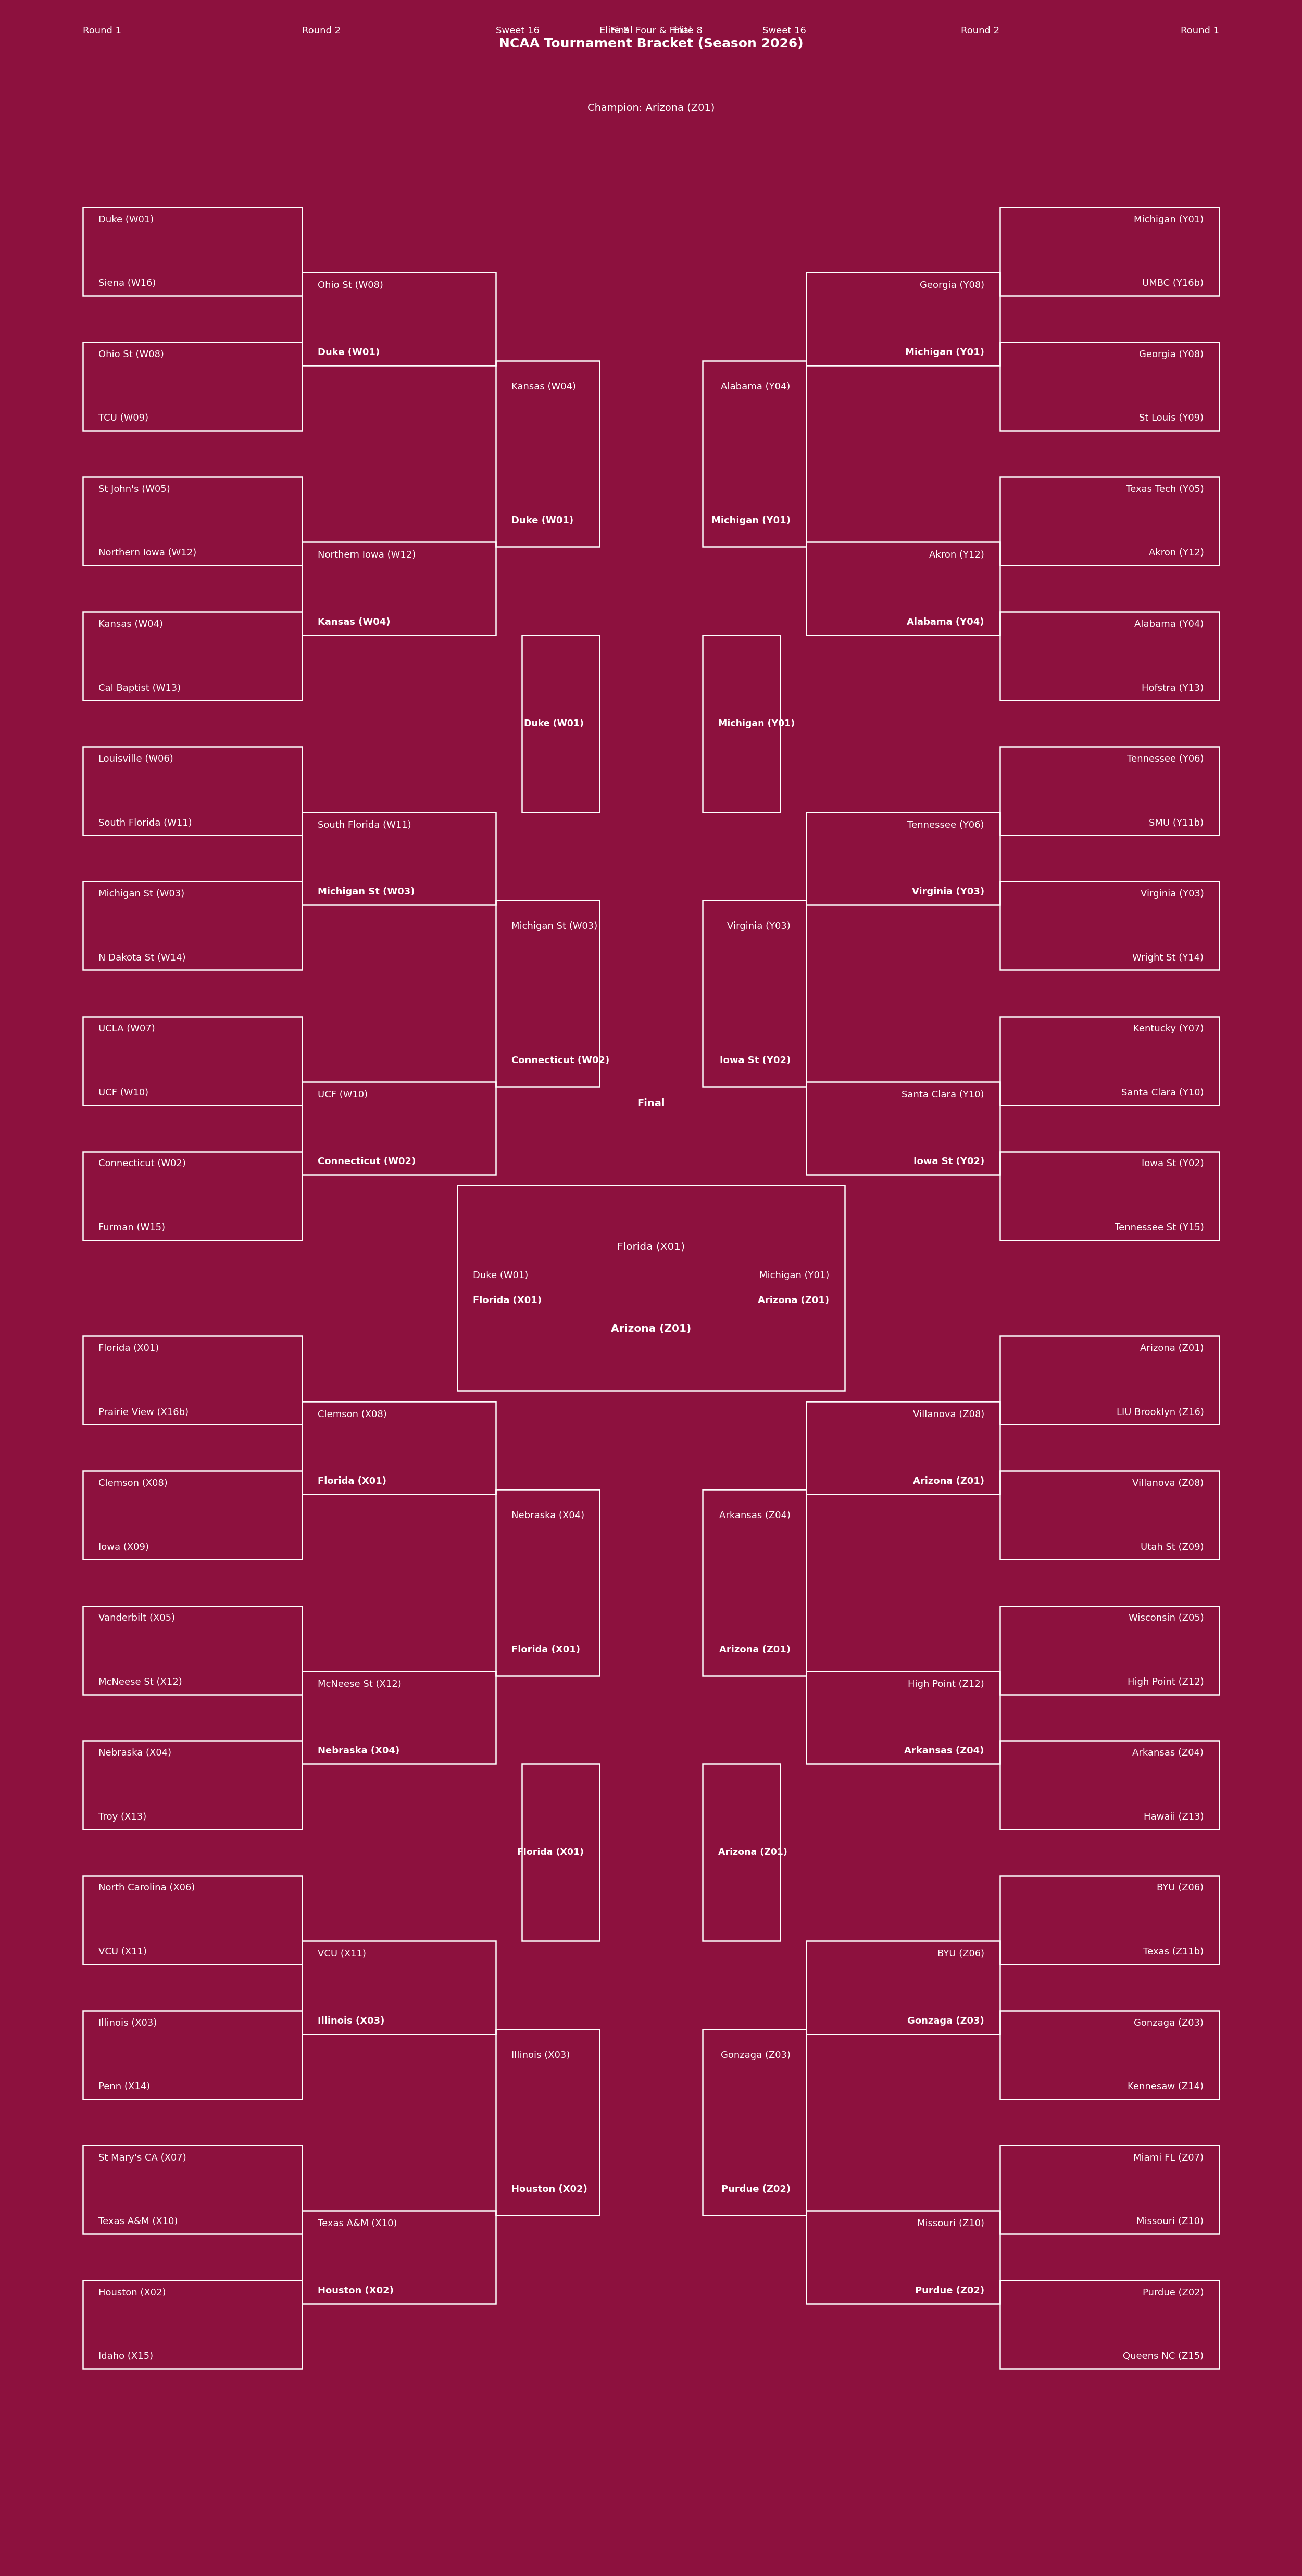

In [21]:
# Render the upset‑favoring bracket
render_bracket(
    match_meta_upset, round_of, latest_season, champ_name, champ_seed,
    left_regions=('W', 'X'), right_regions=('Y', 'Z'),
    fig_w=16, fig_h=8,
    bg_color="#8D113E", text_color='white'
)

In [22]:
# Get the final match from the latest round
final_match = None
max_round = max(round_of.get(m["slot"], -1) for m in match_meta)
for m in match_meta:
    if round_of.get(m["slot"], -1) == max_round:
        final_match = m
        break

if final_match:
    seed_a = final_match["seedA"]
    seed_b = final_match["seedB"]

    # Labels are "Team Name (Seed)" -> extract team names
    team_a_name = final_match["A"].split(" (")[0]
    team_b_name = final_match["B"].split(" (")[0]

    # team_name is {TeamID: TeamName}, so invert for lookup
    name_to_id = {v: k for k, v in team_name.items()}
    team_a_id = name_to_id.get(team_a_name)
    team_b_id = name_to_id.get(team_b_name)

    if team_a_id is not None and team_b_id is not None:
        scores_a, scores_b = simulate_final_score(team_a_id, team_b_id, seed_a, seed_b)
        print(f"\nSimulated final scores (Team A: {final_match['A']} vs Team B: {final_match['B']}):")
        print(f"  Team A average score: {scores_a.mean():.1f}")
        print(f"  Team B average score: {scores_b.mean():.1f}")
        print(f"  Team A wins {np.mean(scores_a > scores_b) * 100:.1f}% of simulations")
    else:
        print("Could not resolve team IDs for finalists; skipping score simulation.")
else:
    print("Final match not found in match_meta; skipping score simulation.")



Simulated final scores (Team A: Florida (X01) vs Team B: Arizona (Z01)):
  Team A average score: 73.6
  Team B average score: 76.5
  Team A wins 43.9% of simulations
